# Indian Stock Price Prediction Model using RNN-LSTM-GRU

Name: Amitesh Ranjan </br>
Scholar No.: 25212011110</br>
Branch: M.Tech CN</br>

## Step 1: Import Library

In [2]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU, Dropout

## Step 2: Load the dataset from yfinance

In [3]:
# RELIANCE.NS is Reliance Industries on the National Stock Exchange (NSE)
ticker = 'RELIANCE.NS'
print(f"Downloading data for {ticker}...")
data = yf.download(ticker, start='2015-01-01', end='2026-01-01')

# We will use the 'Close' price for prediction
df = data[['Close']].dropna()
df.head()

/tmp/ipykernel_55/1305129352.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start='2015-01-01', end='2026-01-01')
[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,RELIANCE.NS
Date,
2015-01-01,189.999802
2015-01-02,189.496933
2015-01-05,187.421249
2015-01-06,178.915222
2015-01-07,182.809830


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2716 entries, 2015-01-01 to 2025-12-31
Data columns (total 1 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   (Close, RELIANCE.NS)  2716 non-null   float64
dtypes: float64(1)
memory usage: 42.4 KB


## Step 3: Data Preprocessing

In [7]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df)
scaled_data

array([[0.01166193],
       [0.01130671],
       [0.00984047],
       ...,
       [0.96924511],
       [0.96514809],
       [0.98676363]])

In [8]:
# Create sequences
# We will use the past 60 days to predict the next day's price
sequence_length = 60

X, y = [], []
for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i, 0])
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)

In [9]:
# Reshape X for Keras models [samples, time steps, features]
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# Split into Training (80%) and Testing (20%) sets
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
actual_prices = df.iloc[split + sequence_length:].values

## Step 4: Build Model RNN, LSTM and GRU

In [10]:
# --- 3. Model Building Functions ---
def build_model(model_type, input_shape):
    model = Sequential()
    
    if model_type == 'RNN':
        model.add(SimpleRNN(units=50, return_sequences=True, input_shape=input_shape))
        model.add(Dropout(0.2))
        model.add(SimpleRNN(units=50))
    elif model_type == 'LSTM':
        model.add(LSTM(units=50, return_sequences=True, input_shape=input_shape))
        model.add(Dropout(0.2))
        model.add(LSTM(units=50))
    elif model_type == 'GRU':
        model.add(GRU(units=50, return_sequences=True, input_shape=input_shape))
        model.add(Dropout(0.2))
        model.add(GRU(units=50))
        
    model.add(Dropout(0.2))
    model.add(Dense(units=1)) # Prediction output
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

## Step 5: Train and Evaluate The Model

In [11]:
models = ['RNN', 'LSTM', 'GRU']
predictions = {}

for m in models:
    print(f"\n--- Training {m} Model ---")
    model = build_model(m, (X_train.shape[1], 1))
    
    # Fit the model (using a small number of epochs for speed; increase for better results)
    model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test), verbose=1)
    
    # Predict and inverse transform to get actual price values back
    pred_scaled = model.predict(X_test)
    predictions[m] = scaler.inverse_transform(pred_scaled)


--- Training RNN Model ---


I0000 00:00:1777220544.955503      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777220544.961425      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10


I0000 00:00:1777220549.024279     207 service.cc:152] XLA service 0x793194004340 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777220549.024315     207 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777220549.024319     207 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777220549.438203     207 cuda_dnn.cc:529] Loaded cuDNN version 91002


16/67 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1169

...

67/67 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - loss: 0.0740 - val_loss: 0.0012
Epoch 2/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0167 - val_loss: 0.0011
Epoch 3/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0091 - val_loss: 0.0047
Epoch 4/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0069 - val_loss: 5.0122e-04
Epoch 5/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0050 - val_loss: 7.4455e-04
Epoch 6/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0048 - val_loss: 4.8732e-04
Epoch 7/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0034 - val_loss: 0.0018
Epoch 8/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0037 - val_loss: 0.0023
Epoch 9/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0032 - val_loss: 4.7677e-04
Epoch 10/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0027 - val_loss: 8.6474e-04
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step

--- Training LSTM Model ---
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0265 - val_loss: 0.0015
Epoch 2/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0022 - val_loss: 0.0011
Epoch 3/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0020 - val_loss: 7.9999e-04
Epoch 4/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0019 - val_loss: 0.0031
Epoch 5/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0019 - val_loss: 0.0027
Epoch 6/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0017 - val_loss: 0.0016
Epoch 7/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0016 - val_loss: 0.0047
Epoch 8/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0015 - val_loss: 0.0033
Epoch 9/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0018 - val_loss: 0.0015
Epoch 10/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0015 - val_loss: 7.6984e-04
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

--- Training GRU Model ---
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0326 - val_loss: 0.0024
Epoch 2/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0024 - val_loss: 4.0363e-04
Epoch 3/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0020 - val_loss: 5.9998e-04
Epoch 4/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0017 - val_loss: 4.0279e-04
Epoch 5/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0017 - val_loss: 4.7251e-04
Epoch 6/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0016 - val_loss: 0.0017
Epoch 7/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0015 - val_loss: 5.8802e-04
Epoch 8/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0015 - val_loss: 3.9329e-04
Epoch 9/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0012 - val_loss: 0.0016
Epoch 10/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0013 - val_loss: 4.0113e-04
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


## Visualization

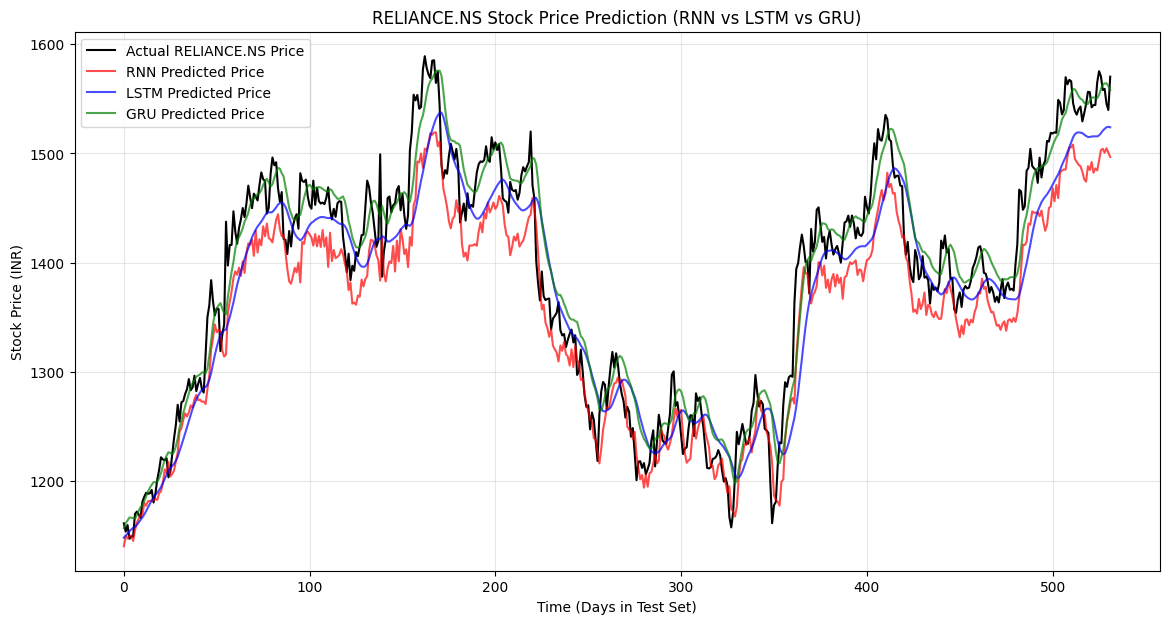

In [12]:
# Visualization ---
plt.figure(figsize=(14, 7))
plt.plot(actual_prices, color='black', label=f'Actual {ticker} Price')

# Plot predictions for each model
colors = {'RNN': 'red', 'LSTM': 'blue', 'GRU': 'green'}
for m in models:
    plt.plot(predictions[m], color=colors[m], label=f'{m} Predicted Price', alpha=0.7)

plt.title(f'{ticker} Stock Price Prediction (RNN vs LSTM vs GRU)')
plt.xlabel('Time (Days in Test Set)')
plt.ylabel('Stock Price (INR)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

print("\n--- Model Evaluation Metrics ---")

for m in models:
    # Calculate the different error metrics
    mae = mean_absolute_error(actual_prices, predictions[m])
    rmse = np.sqrt(mean_squared_error(actual_prices, predictions[m]))
    
    # MAPE is highly interpretable because it gives you a percentage error
    mape = mean_absolute_percentage_error(actual_prices, predictions[m]) * 100 
    
    print(f"\n{m} Model Performance:")
    print(f"MAE:  ₹{mae:.2f} (Average miss in Rupees)")
    print(f"RMSE: ₹{rmse:.2f}")
    print(f"MAPE: {mape:.2f}% (Average miss in percentage)")